
# Bondview Duration — Corrected 6M Trend Stabilization Review

This notebook reruns the **Trend State-stabilization** diagnostics on the correct
6M Yield Trend definition:

```text
Trend Value = M5(t) - M5(t-126)
Trend entry threshold = ±25 bp for every representative tenor
```

The candidate mechanics are exactly the simple variants discussed after the
threshold review:

```text
plain
persistence-2
persistence-3
hysteresis-5 bp
hysteresis-10 bp
```

`hysteresis-5 bp` means directional entry at ±25 bp and directional exit through
±20 bp. `hysteresis-10 bp` means entry at ±25 bp and exit through ±15 bp.

## Why this is a new notebook

The existing `bondview_duration_trend_horizon_6m_9m_12m_review.ipynb` answers a
different question: **which Trend horizon best represents the broader directional
condition?** That review should remain intact.

The existing `bondview_duration_2022_10y_trend_visual_check.ipynb` is tied to the
now-discarded 3M Trend and one historical episode.

This notebook therefore isolates the next question:

> Given the 6M Trend and common ±25 bp threshold, does simple persistence or
> hysteresis improve State stability without creating excessive inertia?

## Guardrails

- Use the frozen Task-1 6M Trend output; do not refresh market data.
- Do not change the Trend horizon, Recent Move, endpoint smoothing, or Core Rule Mapping.
- Do not use forward returns or ETF returns as labels.
- Do not optimize for the smoothest possible State path.
- Short directional episodes are diagnostic, not an objective by themselves.
- Historical episodes are counterexamples / interpretation checks, not supervised labels.


In [3]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)

TREND_THRESHOLD_BP = 25.0
SHORT_EPISODE_MAX_OBS = 5

def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start, *start.parents, Path("/home/lbk/works/bondview-v2")]
    seen = set()
    for p in candidates:
        p = p.resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "validation/261002_duration/task1_core/results.csv").exists():
            return p
    raise FileNotFoundError(
        "Could not find bondview-v2 repository root. "
        "Run this notebook from inside the repository or edit REPO_ROOT manually."
    )

REPO_ROOT = find_repo_root()
TASK1 = REPO_ROOT / "validation/261002_duration/task1_core/results.csv"

print("REPO_ROOT:", REPO_ROOT)
print("TASK1:", TASK1)


REPO_ROOT: /home/lbk/works/bondview-v2
TASK1: /home/lbk/works/bondview-v2/validation/261002_duration/task1_core/results.csv



## 1. Load the frozen 6M Trend baseline

Task 1 already contains the 6M endpoint-change Trend:

```text
M5(t) - M5(t-126)
```

Only observations with an authoritative `trend_state`, `trend_bp`, and structural
`segment` are retained. State machines are reset at segment boundaries, so the
30Y structural gap is never bridged.


In [4]:

task1 = pd.read_csv(TASK1, parse_dates=["as_of"])

required = {
    "as_of", "representative_tenor", "duration_exposure",
    "segment", "trend_bp", "trend_state",
    "recent_move_bp", "recent_move_state",
}
missing = required - set(task1.columns)
if missing:
    raise ValueError(f"Task-1 results.csv is missing expected columns: {sorted(missing)}")

base = (
    task1.loc[
        task1["trend_state"].notna()
        & task1["trend_bp"].notna()
        & task1["segment"].notna()
    ]
    .copy()
)

base["segment"] = base["segment"].astype(int)
base = base.sort_values(
    ["representative_tenor", "segment", "as_of"]
).reset_index(drop=True)

print("Classified 6M Trend observations:", len(base))
display(
    base.groupby("representative_tenor")
    .size()
    .rename("n")
    .to_frame()
)


Classified 6M Trend observations: 38330


,n
representative_tenor,
10Y,16042
30Y,11148
6M,11140



### Baseline sanity check

The plain ±25 bp classifier must reproduce the committed Task-1 6M Trend State
exactly before any stabilization rule is evaluated.


In [5]:

def classify_plain(value, threshold=TREND_THRESHOLD_BP):
    if pd.isna(value):
        return pd.NA
    if value < -threshold:
        return "Falling"
    if value > threshold:
        return "Rising"
    return "Stable"

base["plain_state"] = base["trend_bp"].map(classify_plain)
mismatches = base["plain_state"].ne(base["trend_state"]).sum()

print("Plain-classifier mismatches versus committed Task-1 Trend State:", mismatches)
assert mismatches == 0


Plain-classifier mismatches versus committed Task-1 Trend State: 0



## 2. Stabilization mechanics

### Persistence

A new candidate State must appear for `N` consecutive valid observations before
it replaces the active State. Until confirmation, the previous active State is
retained.

This rule applies to every State transition, so persistence necessarily adds
recognition lag to genuine transitions as well as suppressing short excursions.

### Hysteresis

Directional States enter at the common ±25 bp threshold.

For a 5 bp hysteresis band:

```text
Stable → Rising    when Trend > +25
Rising → Stable    when Trend <= +20

Stable → Falling   when Trend < -25
Falling → Stable   when Trend >= -20
```

For a 10 bp hysteresis band, the corresponding exit levels are ±15 bp.

A direct move across the opposite ±25 bp entry boundary can move directly to the
opposite directional State. Hysteresis therefore does **not** delay entry into a
new directional State from Stable; it mainly prevents immediate exit near the
entry boundary.


In [6]:

def apply_persistence(raw_states, required_n):
    raw_states = list(raw_states)
    if not raw_states:
        return []

    active = raw_states[0]
    pending = None
    count = 0
    out = [active]

    for candidate in raw_states[1:]:
        if candidate == active:
            pending = None
            count = 0
        else:
            if candidate == pending:
                count += 1
            else:
                pending = candidate
                count = 1

            if count >= required_n:
                active = pending
                pending = None
                count = 0

        out.append(active)

    return out


def apply_hysteresis(values, entry_bp=25.0, exit_bp=20.0):
    values = list(values)
    if not values:
        return []

    active = classify_plain(values[0], entry_bp)
    out = [active]

    for value in values[1:]:
        if active == "Stable":
            active = classify_plain(value, entry_bp)

        elif active == "Rising":
            if value < -entry_bp:
                active = "Falling"
            elif value <= exit_bp:
                active = "Stable"

        elif active == "Falling":
            if value > entry_bp:
                active = "Rising"
            elif value >= -exit_bp:
                active = "Stable"

        out.append(active)

    return out


VARIANTS = {
    "plain": lambda values, raw: list(raw),
    "persistence_2": lambda values, raw: apply_persistence(raw, 2),
    "persistence_3": lambda values, raw: apply_persistence(raw, 3),
    "hysteresis_5bp": lambda values, raw: apply_hysteresis(values, 25.0, 20.0),
    "hysteresis_10bp": lambda values, raw: apply_hysteresis(values, 25.0, 15.0),
}



## 3. Apply variants within each tenor / structural segment


In [7]:

parts = []

for (tenor, segment), g in base.groupby(
    ["representative_tenor", "segment"], sort=False
):
    g = g.sort_values("as_of").copy()

    values = g["trend_bp"].astype(float).tolist()
    raw = g["plain_state"].astype(str).tolist()

    for name, fn in VARIANTS.items():
        g[f"state_{name}"] = fn(values, raw)

    parts.append(g)

review = pd.concat(parts, ignore_index=True)

display(
    review[
        [
            "as_of", "representative_tenor", "segment", "trend_bp",
            *[f"state_{name}" for name in VARIANTS],
        ]
    ].head()
)


,as_of,representative_tenor,segment,trend_bp,state_plain,state_persistence_2,state_persistence_3,state_hysteresis_5bp,state_hysteresis_10bp
0,1962-07-10,10Y,1,-0.8,Stable,Stable,Stable,Stable,Stable
1,1962-07-11,10Y,1,-0.8,Stable,Stable,Stable,Stable,Stable
2,1962-07-12,10Y,1,-1.6,Stable,Stable,Stable,Stable,Stable
3,1962-07-13,10Y,1,-3.8,Stable,Stable,Stable,Stable,Stable
4,1962-07-16,10Y,1,-5.8,Stable,Stable,Stable,Stable,Stable



## 4. Summary diagnostics

The main diagnostics are:

- **short directional episode %**: share of Rising/Falling episodes lasting
  five valid observations or fewer;
- **transition %**: State changes as a share of eligible adjacent observations;
- **median directional episode**: median length of Rising/Falling episodes;
- **Stable %**: share of observations classified Stable;
- **changed vs plain %**: share of observations whose stabilized State differs
  from the plain ±25 bp State.

The goal is not to minimize any one metric. A useful stabilizer should reduce
boundary-driven short episodes without materially delaying or distorting genuine
directional changes.


In [8]:

def directional_episode_lengths(frame, state_col):
    lengths = []

    for (_, _), g in frame.groupby(
        ["representative_tenor", "segment"], sort=False
    ):
        g = g.sort_values("as_of")
        s = g[state_col].astype(str)
        episode_id = s.ne(s.shift()).cumsum()

        for _, ep in g.groupby(episode_id):
            state = str(ep[state_col].iloc[0])
            if state != "Stable":
                lengths.append(len(ep))

    return np.asarray(lengths, dtype=int)


def transition_rate(frame, state_col):
    transitions = 0
    pairs = 0

    for (_, _), g in frame.groupby(
        ["representative_tenor", "segment"], sort=False
    ):
        g = g.sort_values("as_of")
        s = g[state_col].astype(str).to_numpy()

        if len(s) < 2:
            continue

        pairs += len(s) - 1
        transitions += np.count_nonzero(s[1:] != s[:-1])

    return transitions, pairs, transitions / pairs if pairs else np.nan


summary_rows = []

for tenor, g in review.groupby("representative_tenor", sort=False):
    plain = g["state_plain"].astype(str)

    for variant in VARIANTS:
        state_col = f"state_{variant}"
        states = g[state_col].astype(str)
        lens = directional_episode_lengths(g, state_col)
        transitions, pairs, rate = transition_rate(g, state_col)

        summary_rows.append({
            "tenor": tenor,
            "variant": variant,
            "short_directional_episode_%": (
                100 * np.mean(lens <= SHORT_EPISODE_MAX_OBS)
                if len(lens) else np.nan
            ),
            "transition_%": 100 * rate,
            "median_directional_episode_obs": (
                np.median(lens) if len(lens) else np.nan
            ),
            "Stable_%": 100 * np.mean(states == "Stable"),
            "changed_vs_plain_%": 100 * np.mean(states != plain),
            "directional_episodes": len(lens),
            "n_obs": len(g),
        })

summary = pd.DataFrame(summary_rows)
display(summary.round(2))


,tenor,variant,short_directional_episode_%,transition_%,median_directional_episode_obs,Stable_%,changed_vs_plain_%,directional_episodes,n_obs
0,10Y,plain,23.48,2.86,20.0,31.14,0.00,230,16042
1,10Y,persistence_2,16.83,2.59,23.5,31.21,2.72,208,16042
2,10Y,persistence_3,14.65,2.44,26.5,31.19,5.20,198,16042
3,10Y,hysteresis_5bp,11.79,2.43,29.0,28.63,2.51,195,16042
4,10Y,hysteresis_10bp,5.39,2.08,37.0,25.51,5.64,167,16042
5,30Y,plain,24.10,2.96,15.0,28.72,0.00,166,11148
6,30Y,persistence_2,19.21,2.69,19.0,28.75,2.83,151,11148
7,30Y,persistence_3,11.03,2.42,32.0,28.78,5.26,136,11148
8,30Y,hysteresis_5bp,10.85,2.30,34.0,25.72,3.01,129,11148
9,30Y,hysteresis_10bp,4.59,1.94,47.0,22.43,6.29,109,11148



### Corrected 6M rerun results

These are the results from the corrected full Task-1 sample (`n = 38,330`).

| Tenor | Variant | Short directional episodes ≤5 (%) | Transition (%) | Median directional episode (obs) | Stable (%) | Changed vs plain (%) |
|---|---|---:|---:|---:|---:|---:|
| 6M | plain | 29.35 | 1.63 | 15.0 | 38.86 | 0.00 |
| 6M | persistence-2 | 23.53 | 1.50 | 19.0 | 38.86 | 1.57 |
| 6M | persistence-3 | 17.57 | 1.28 | 29.5 | 38.81 | 2.87 |
| 6M | hysteresis-5 | 10.61 | 1.17 | 37.0 | 36.89 | 1.97 |
| 6M | hysteresis-10 | 8.77 | 1.01 | 44.0 | 34.92 | 3.94 |
| 10Y | plain | 23.48 | 2.86 | 20.0 | 31.14 | 0.00 |
| 10Y | persistence-2 | 16.83 | 2.59 | 23.5 | 31.21 | 2.72 |
| 10Y | persistence-3 | 14.65 | 2.44 | 26.5 | 31.19 | 5.20 |
| 10Y | hysteresis-5 | 11.79 | 2.43 | 29.0 | 28.63 | 2.51 |
| 10Y | hysteresis-10 | 5.39 | 2.08 | 37.0 | 25.51 | 5.64 |
| 30Y | plain | 24.10 | 2.96 | 15.0 | 28.72 | 0.00 |
| 30Y | persistence-2 | 19.21 | 2.69 | 19.0 | 28.75 | 2.83 |
| 30Y | persistence-3 | 11.03 | 2.42 | 32.0 | 28.78 | 5.26 |
| 30Y | hysteresis-5 | 10.85 | 2.30 | 34.0 | 25.72 | 3.01 |
| 30Y | hysteresis-10 | 4.59 | 1.94 | 47.0 | 22.43 | 6.29 |

The important comparison is not simply “which is smoothest.” `hysteresis-5`
reduces short directional episodes much more than persistence-2 and somewhat more
than persistence-3, while changing fewer observations than persistence-3 for all
three tenors. `hysteresis-10` is materially more aggressive and removes a larger
share of Stable observations.


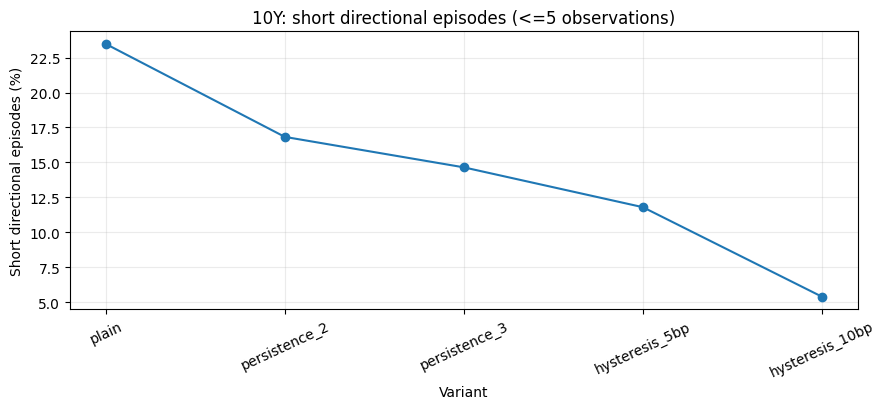

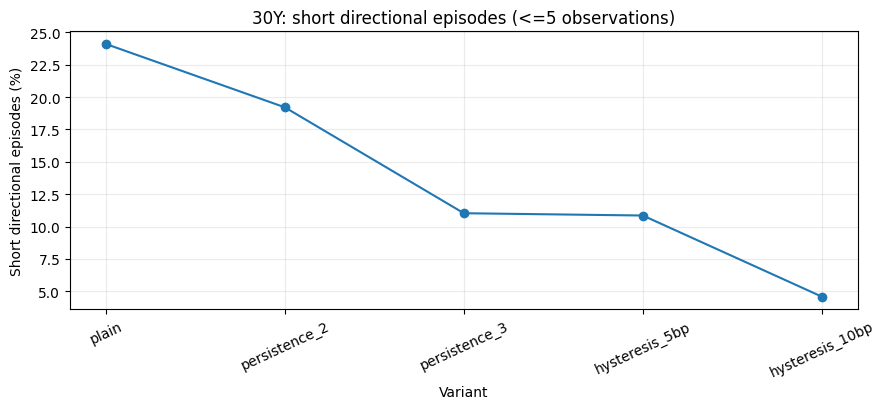

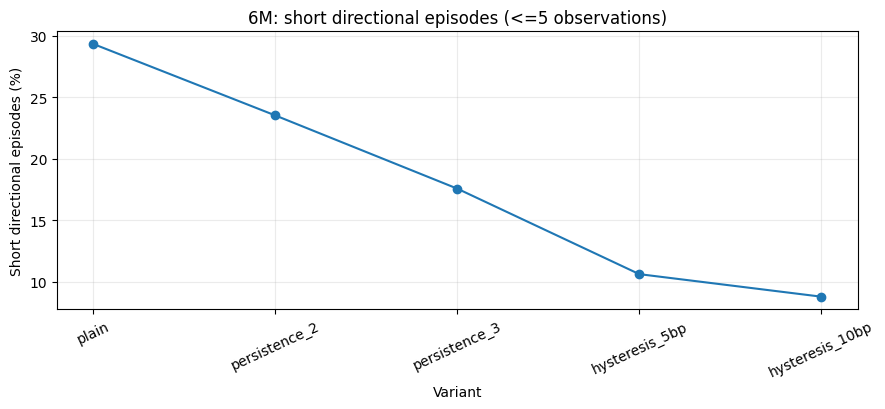

In [9]:

plot_order = [
    "plain",
    "persistence_2",
    "persistence_3",
    "hysteresis_5bp",
    "hysteresis_10bp",
]

plot_df = summary.copy()
plot_df["variant"] = pd.Categorical(
    plot_df["variant"], categories=plot_order, ordered=True
)

for tenor, g in plot_df.groupby("tenor", sort=False):
    g = g.sort_values("variant")
    plt.figure(figsize=(9, 4.2))
    plt.plot(
        g["variant"].astype(str),
        g["short_directional_episode_%"],
        marker="o",
    )
    plt.title(f"{tenor}: short directional episodes (<=5 observations)")
    plt.xlabel("Variant")
    plt.ylabel("Short directional episodes (%)")
    plt.xticks(rotation=25)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()



## 5. Historical challenge review

Aggregate smoothness is insufficient. The helper below compares State episodes
inside selected historical windows.

Useful questions:

1. Does the stabilizer suppress only boundary churn, or does it delay genuine reversals?
2. Does it preserve economically legitimate broad Trend persistence?
3. Does it create a directional State that survives too far into a genuinely
   neutral or opposite regime?

The main comparison below focuses on `plain`, `persistence_3`, and
`hysteresis_5bp`, because they make the tradeoff easiest to see.


In [10]:

EVENTS = {
    "1980_10Y": {
        "label": "1980 reversal — 10Y",
        "tenor": "10Y",
        "start": "1980-06-01",
        "end": "1980-11-30",
    },
    "1980_30Y": {
        "label": "1980 reversal — 30Y",
        "tenor": "30Y",
        "start": "1980-06-01",
        "end": "1980-11-30",
    },
    "1987_10Y": {
        "label": "1987 reversal — 10Y",
        "tenor": "10Y",
        "start": "1987-08-01",
        "end": "1987-11-30",
    },
    "2008_10Y": {
        "label": "2008 GFC — 10Y",
        "tenor": "10Y",
        "start": "2008-08-01",
        "end": "2009-01-31",
    },
    "2008_30Y": {
        "label": "2008 GFC — 30Y",
        "tenor": "30Y",
        "start": "2008-08-01",
        "end": "2009-01-31",
    },
    "2022_10Y": {
        "label": "2022 relief / re-tightening — 10Y",
        "tenor": "10Y",
        "start": "2022-06-01",
        "end": "2022-10-31",
    },
    "2022_30Y": {
        "label": "2022 relief / re-tightening — 30Y",
        "tenor": "30Y",
        "start": "2022-06-01",
        "end": "2022-10-31",
    },
    "2023_30Y": {
        "label": "2023 long-end selloff — 30Y",
        "tenor": "30Y",
        "start": "2023-06-01",
        "end": "2023-11-30",
    },
}

STATE_CODE = {"Falling": -1, "Stable": 0, "Rising": 1}
COMPARE_VARIANTS = ["plain", "persistence_3", "hysteresis_5bp"]


def event_frame(key):
    e = EVENTS[key]
    frame = (
        review.loc[
            (review["representative_tenor"] == e["tenor"])
            & review["as_of"].between(
                pd.Timestamp(e["start"]),
                pd.Timestamp(e["end"]),
            )
        ]
        .sort_values("as_of")
        .copy()
    )
    if frame.empty:
        raise ValueError(f"No observations for {key}")
    return e, frame


def episode_table(frame, variants=COMPARE_VARIANTS):
    rows = []

    for variant in variants:
        state_col = f"state_{variant}"
        s = frame[state_col].astype(str)
        episode_id = s.ne(s.shift()).cumsum()

        for _, ep in frame.groupby(episode_id):
            rows.append({
                "variant": variant,
                "state": str(ep[state_col].iloc[0]),
                "start": ep["as_of"].iloc[0],
                "end": ep["as_of"].iloc[-1],
                "n": len(ep),
                "min_trend_bp": ep["trend_bp"].min(),
                "max_trend_bp": ep["trend_bp"].max(),
            })

    return pd.DataFrame(rows)


def review_event(key):
    e, frame = event_frame(key)
    print(
        f"{e['label']} | {e['tenor']} | "
        f"{frame['as_of'].min().date()} to {frame['as_of'].max().date()} "
        f"| n={len(frame)}"
    )

    plt.figure(figsize=(12, 4.5))
    plt.plot(frame["as_of"], frame["trend_bp"], label="6M Trend")
    plt.axhline(25, linestyle="--", linewidth=1, label="entry ±25 bp")
    plt.axhline(-25, linestyle="--", linewidth=1)
    plt.axhline(20, linestyle=":", linewidth=1, label="5 bp hysteresis exit ±20 bp")
    plt.axhline(-20, linestyle=":", linewidth=1)
    plt.axhline(0, linewidth=0.8)
    plt.title(f"{e['label']} — 6M Trend value")
    plt.xlabel("Date")
    plt.ylabel("Trend (bp)")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4.0))
    for variant in COMPARE_VARIANTS:
        plt.step(
            frame["as_of"],
            frame[f"state_{variant}"].map(STATE_CODE),
            where="post",
            label=variant,
        )
    plt.yticks([-1, 0, 1], ["Falling", "Stable", "Rising"])
    plt.title(f"{e['label']} — State paths")
    plt.xlabel("Date")
    plt.ylabel("Trend State")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(
        episode_table(frame).round(
            {"min_trend_bp": 1, "max_trend_bp": 1}
        )
    )


1980 reversal — 10Y | 10Y | 1980-06-02 to 1980-11-28 | n=124


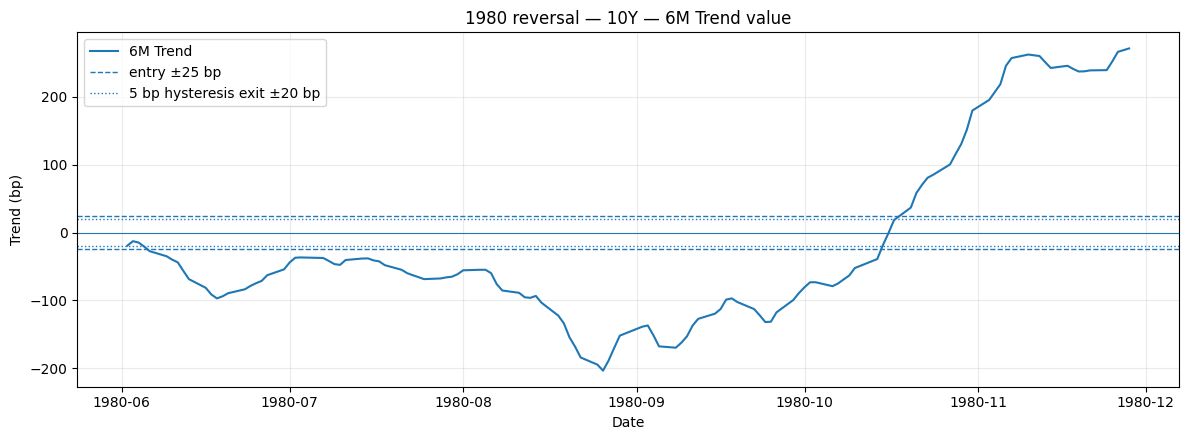

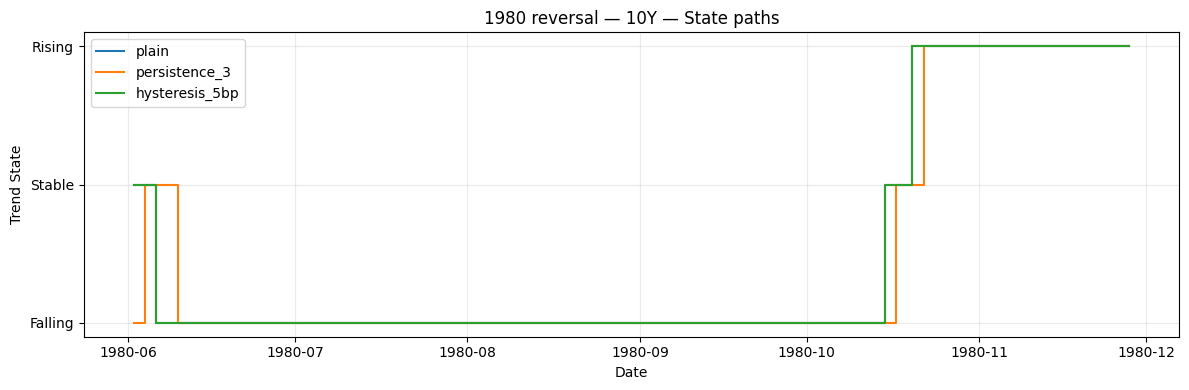

,variant,state,start,end,n,min_trend_bp,max_trend_bp
0,plain,Stable,1980-06-02,1980-06-05,4,-20.8,-12.8
1,plain,Falling,1980-06-06,1980-10-14,90,-203.8,-27.6
2,plain,Stable,1980-10-15,1980-10-17,3,-18.8,18.4
3,plain,Rising,1980-10-20,1980-11-28,27,36.8,271.6
4,persistence_3,Falling,1980-06-02,1980-06-03,2,-19.4,-12.8
5,persistence_3,Stable,1980-06-04,1980-06-09,4,-35.0,-14.8
6,persistence_3,Falling,1980-06-10,1980-10-16,90,-203.8,-1.0
7,persistence_3,Stable,1980-10-17,1980-10-21,3,18.4,58.4
8,persistence_3,Rising,1980-10-22,1980-11-28,25,70.4,271.6
9,hysteresis_5bp,Stable,1980-06-02,1980-06-05,4,-20.8,-12.8


2008 GFC — 30Y | 30Y | 2008-08-01 to 2009-01-30 | n=124


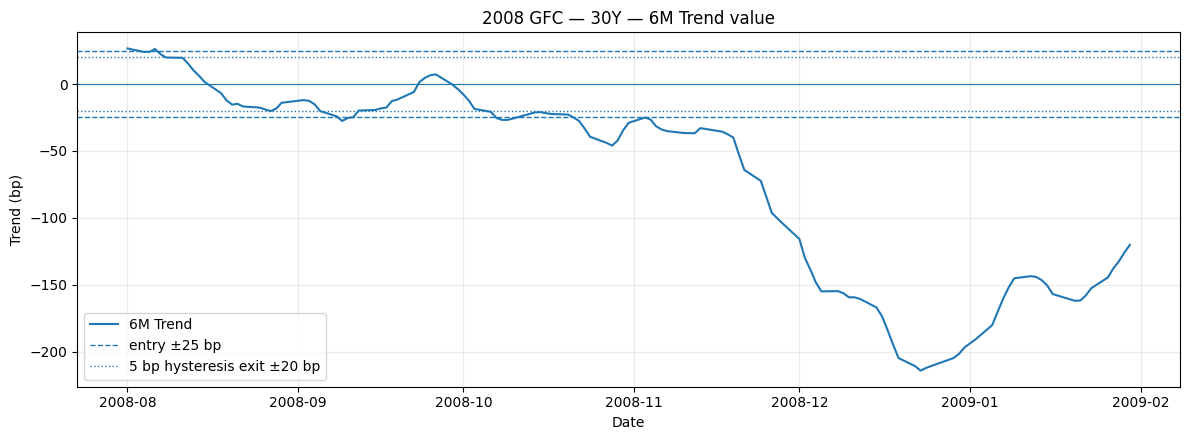

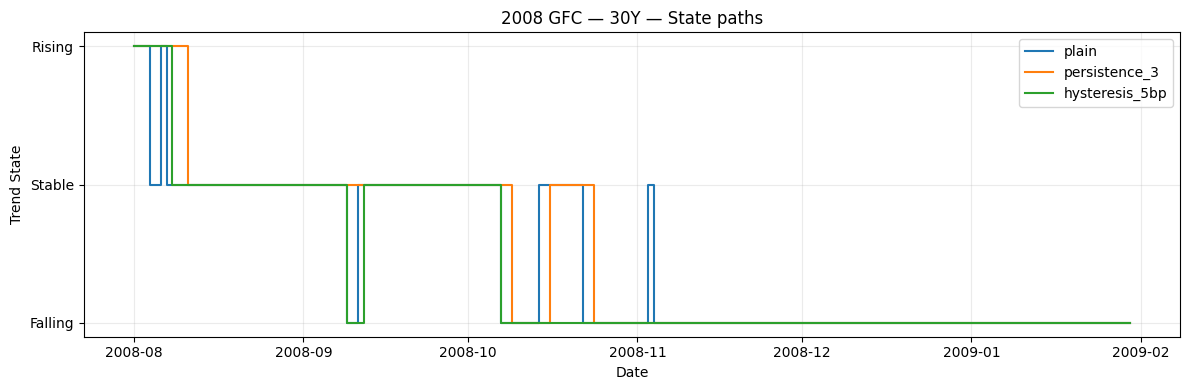

,variant,state,start,end,n,min_trend_bp,max_trend_bp
0,plain,Rising,2008-08-01,2008-08-01,1,26.6,26.6
1,plain,Stable,2008-08-04,2008-08-05,2,24.0,24.0
2,plain,Rising,2008-08-06,2008-08-06,1,26.2,26.2
3,plain,Stable,2008-08-07,2008-09-08,22,-24.2,22.4
4,plain,Falling,2008-09-09,2008-09-10,2,-27.6,-25.4
5,plain,Stable,2008-09-11,2008-10-06,18,-24.8,7.2
6,plain,Falling,2008-10-07,2008-10-10,4,-26.8,-25.4
7,plain,Stable,2008-10-14,2008-10-21,6,-25.0,-21.0
8,plain,Falling,2008-10-22,2008-10-31,8,-46.0,-27.6
9,plain,Stable,2008-11-03,2008-11-03,1,-25.0,-25.0


2022 relief / re-tightening — 10Y | 10Y | 2022-06-01 to 2022-10-31 | n=105


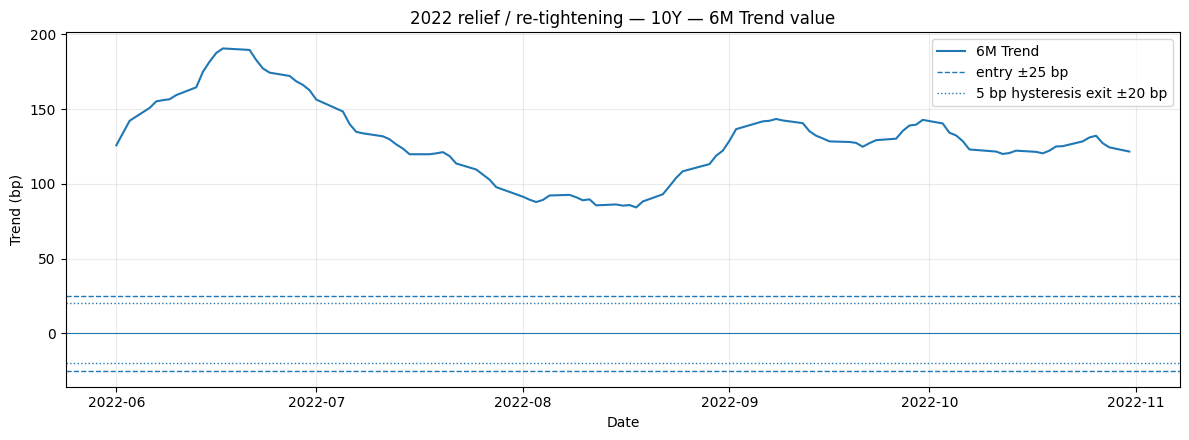

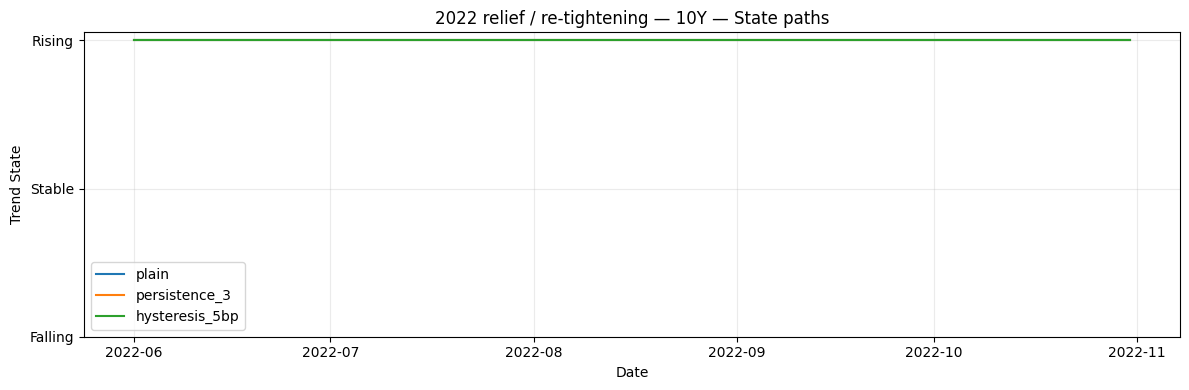

,variant,state,start,end,n,min_trend_bp,max_trend_bp
0,plain,Rising,2022-06-01,2022-10-31,105,84.2,190.6
1,persistence_3,Rising,2022-06-01,2022-10-31,105,84.2,190.6
2,hysteresis_5bp,Rising,2022-06-01,2022-10-31,105,84.2,190.6


2023 long-end selloff — 30Y | 30Y | 2023-06-01 to 2023-11-30 | n=126


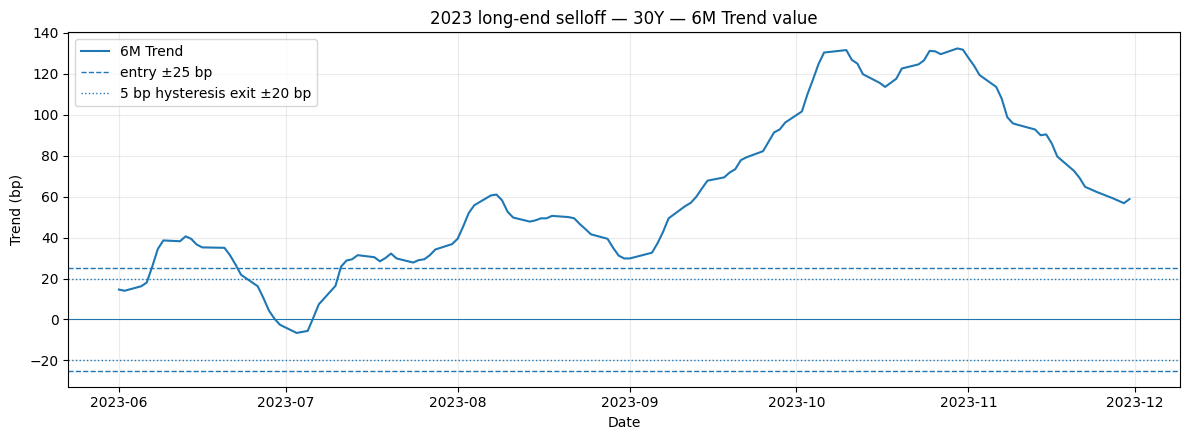

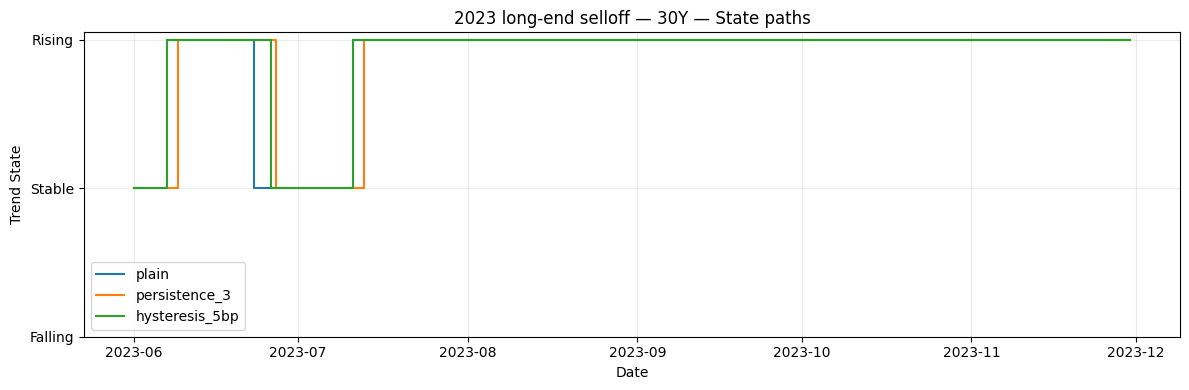

,variant,state,start,end,n,min_trend_bp,max_trend_bp
0,plain,Stable,2023-06-01,2023-06-06,4,14.0,18.0
1,plain,Rising,2023-06-07,2023-06-22,11,25.8,40.6
2,plain,Stable,2023-06-23,2023-07-10,11,-6.6,21.8
3,plain,Rising,2023-07-11,2023-11-30,100,25.8,132.4
4,persistence_3,Stable,2023-06-01,2023-06-08,6,14.0,34.4
5,persistence_3,Rising,2023-06-09,2023-06-26,11,16.2,40.6
6,persistence_3,Stable,2023-06-27,2023-07-12,11,-6.6,28.8
7,persistence_3,Rising,2023-07-13,2023-11-30,98,27.8,132.4
8,hysteresis_5bp,Stable,2023-06-01,2023-06-06,4,14.0,18.0
9,hysteresis_5bp,Rising,2023-06-07,2023-06-23,12,21.8,40.6


In [11]:

# Main challenge / counterexample windows.
review_event("1980_10Y")
review_event("2008_30Y")
review_event("2022_10Y")
review_event("2023_30Y")



## 6. Interpretation of the corrected rerun

The corrected 6M test supports the following **provisional** interpretation:

### Plain ±25 bp still shows meaningful boundary instability

Short directional episodes (≤5 valid observations) account for roughly:

```text
6M tenor   29.35%
10Y        23.48%
30Y        24.10%
```

So the instability concern did not disappear when the mistaken 3M Trend was
replaced with the correct 6M Trend.

### Persistence helps, but it delays every confirmed transition

`persistence-3` reduces the short-episode share to:

```text
6M tenor   17.57%
10Y        14.65%
30Y        11.03%
```

but changes about 2.9% / 5.2% / 5.3% of observations versus plain classification.
In challenge windows it typically moves genuine transition dates later by two
valid observations because that delay is built into the rule.

### 5 bp hysteresis is more targeted

`hysteresis-5bp` reduces short directional episodes to:

```text
6M tenor   10.61%
10Y        11.79%
30Y        10.85%
```

while changing about 2.0% / 2.5% / 3.0% of observations.

Because directional entry remains at ±25 bp, clear transitions can still be
recognized on the same date as the plain classifier. The rule mainly prevents a
directional State from disappearing as soon as the Trend retreats only slightly
inside the original ±25 bp boundary.

Examples in the review windows illustrate this distinction:

- **1980 10Y:** 5 bp hysteresis leaves the major plain transition dates unchanged,
  while persistence-3 delays them.
- **2008 10Y:** the decisive Falling transition begins on the same date under
  plain and 5 bp hysteresis; persistence-3 confirms it later.
- **2022 10Y / 30Y:** the 6M Trend remains strongly Rising through the midsummer
  relief, so none of the stabilization rules changes the broad Trend interpretation.
- **2023 30Y:** 5 bp hysteresis preserves the initial Rising entry dates while
  reducing boundary exits; persistence-3 shifts the entries later.

### 10 bp hysteresis looks materially more aggressive

`hysteresis-10bp` produces the smoothest path, but also reduces Stable occupancy
substantially and changes roughly 4–6% of observations. The corrected test does
not establish that this extra stickiness has enough economic benefit to justify it.

## Provisional recommendation

Among these simple candidates, **5 bp hysteresis is the strongest candidate for
the next human review**. It addresses the observed boundary churn more directly
than persistence while avoiding the universal transition delay of a minimum-
persistence rule.

This is **not yet an accepted production rule**. The historical charts and
episode tables above should be inspected before updating the Duration design
contract or proceeding to Macro Adjustment validation.
